# Paso 6: Feature Engineering

Este notebook se enfoca en la creación de features para modelado de riesgo/anomalía.
**NO se entrena ningún modelo aquí**, solo se prepara el dataset final `model_ready`.

## Tipos de Features a Crear:

1. **Features transaccionales**: derivadas de columnas originales (logs, ratios, flags)
2. **Features temporales**: hour, dayofweek, is_weekend, is_night
3. **Features de novedad**: new_device, new_ip, new_merchant, new_location (primera vez por cuenta)
4. **Features de velocidad**: actividad reciente por cuenta (rolling)
5. **Features agregadas**: merge con estadísticas por AccountID, MerchantID, Channel

## Setup: Imports y Configuración

Cargamos librerías, configuramos estilo y verificamos el entorno.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from datetime import timedelta

# Estilo seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")

# Configuración de visualización
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## Cargar Dataset

Si `df` no existe en el entorno, lo cargamos desde el CSV.

In [33]:
df = pd.read_csv('../data/transacciones_banco.csv')
print("✓ Dataset cargado desde archivo CSV")

print(f"\nShape: {df.shape}")
print(f"Columnas: {list(df.columns)}")

✓ Dataset cargado desde archivo CSV

Shape: (2512, 16)
Columnas: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


## Parsear TransactionDate a Datetime

Convertimos `TransactionDate` a datetime para análisis temporal.

In [ ]:
if 'TransactionDate_dt' not in df.columns:
    df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    print("✓ TransactionDate_dt creado")
else:
    print("✓ TransactionDate_dt ya existe")

print(f"Rango de fechas: {df['TransactionDate_dt'].min()} a {df['TransactionDate_dt'].max()}")
print(f"Valores nulos en TransactionDate_dt: {df['TransactionDate_dt'].isna().sum()}")

✓ TransactionDate_dt creado
Rango de fechas: 2023-01-02 16:00:06 a 2024-01-01 18:21:50
Valores nulos en TransactionDate_dt: 0


## Crear Directorios de Salida

Aseguramos que existen las carpetas para guardar outputs.

In [ ]:
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✓ Directorios creados: outputs/tables/ y outputs/figures/")

✓ Directorios creados: outputs/tables/ y outputs/figures/


---
# A) Features Transaccionales

## Feature: amount_log

Logaritmo del monto (log1p para evitar problemas con ceros). Ayuda a normalizar la distribución de montos.

In [ ]:
df['amount_log'] = np.log1p(df['TransactionAmount'])

print(f"✓ amount_log creado")
print(f"  Rango: [{df['amount_log'].min():.2f}, {df['amount_log'].max():.2f}]")
print(f"  Media: {df['amount_log'].mean():.2f}")

✓ amount_log creado
  Rango: [0.23, 7.56]
  Media: 5.14


## Feature: amount_to_balance

Ratio monto/saldo. Indica qué proporción del saldo representa la transacción. Valores altos pueden indicar riesgo.

In [ ]:
df['amount_to_balance'] = df['TransactionAmount'] / (df['AccountBalance'] + 1e-9)

print(f"✓ amount_to_balance creado")
print(f"  P50: {df['amount_to_balance'].median():.4f}")
print(f"  P95: {df['amount_to_balance'].quantile(0.95):.4f}")
print(f"  P99: {df['amount_to_balance'].quantile(0.99):.4f}")

✓ amount_to_balance creado
  P50: 0.0519
  P95: 0.9243
  P99: 2.2890


## Feature: is_online

Flag binario indicando si la transacción fue por canal Online (1) o no (0).

In [ ]:
df['is_online'] = (df['Channel'] == 'Online').astype(int)

print(f"✓ is_online creado")
print(f"  Transacciones online: {df['is_online'].sum()} ({df['is_online'].mean()*100:.1f}%)")

✓ is_online creado
  Transacciones online: 811 (32.3%)


## Feature: is_high_login

Flag indicando si LoginAttempts >= 4 (múltiples intentos pueden ser señal de alerta).

In [ ]:
df['is_high_login'] = (df['LoginAttempts'] >= 3).astype(int)

print(f"✓ is_high_login creado")
print(f"  Transacciones con high login: {df['is_high_login'].sum()} ({df['is_high_login'].mean()*100:.1f}%)")

✓ is_high_login creado
  Transacciones con high login: 95 (3.8%)


## Features Temporales: hour, dayofweek, month

Extraemos componentes temporales de la fecha/hora de transacción.

In [ ]:
df['hour'] = df['TransactionDate_dt'].dt.hour
df['dayofweek'] = df['TransactionDate_dt'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['month'] = df['TransactionDate_dt'].dt.month

print(f"✓ Features temporales creados")
print(f"  hour: rango [0-23], valores únicos: {df['hour'].nunique()}")
print(f"  dayofweek: rango [0-6], valores únicos: {df['dayofweek'].nunique()}")
print(f"  month: rango [1-12], valores únicos: {df['month'].nunique()}")

✓ Features temporales creados
  hour: rango [0-23], valores únicos: 3
  dayofweek: rango [0-6], valores únicos: 5
  month: rango [1-12], valores únicos: 12


## Feature: is_weekend

Flag indicando si la transacción ocurrió en fin de semana (sábado o domingo).

In [ ]:
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print(f"✓ is_weekend creado")
print(f"  Transacciones en fin de semana: {df['is_weekend'].sum()} ({df['is_weekend'].mean()*100:.1f}%)")

✓ is_weekend creado
  Transacciones en fin de semana: 0 (0.0%)


---
# B) Features de Novedad por Cuenta

## Preparación: Ordenar por AccountID y Fecha

Para calcular "primera vez", necesitamos ordenar cronológicamente dentro de cada cuenta.

In [ ]:
df = df.sort_values(['AccountID', 'TransactionDate_dt']).reset_index(drop=True)

print(f"✓ DataFrame ordenado por AccountID y TransactionDate_dt")
print(f"  Shape: {df.shape}")

✓ DataFrame ordenado por AccountID y TransactionDate_dt
  Shape: (2512, 26)


## Feature: new_device_for_account

Indica si el DeviceID es la primera aparición para esa cuenta (1 = nuevo, 0 = ya usado).

In [ ]:
df['new_device_for_account'] = (~df.duplicated(subset=['AccountID', 'DeviceID'], keep='first')).astype(int)

print(f"✓ new_device_for_account creado")
print(f"  Transacciones con dispositivo nuevo: {df['new_device_for_account'].sum()} ({df['new_device_for_account'].mean()*100:.1f}%)")

✓ new_device_for_account creado
  Transacciones con dispositivo nuevo: 2500 (99.5%)


## Feature: new_ip_for_account

Indica si la IP Address es la primera aparición para esa cuenta.

In [ ]:
df['new_ip_for_account'] = (~df.duplicated(subset=['AccountID', 'IP Address'], keep='first')).astype(int)

print(f"✓ new_ip_for_account creado")
print(f"  Transacciones con IP nueva: {df['new_ip_for_account'].sum()} ({df['new_ip_for_account'].mean()*100:.1f}%)")

✓ new_ip_for_account creado
  Transacciones con IP nueva: 2499 (99.5%)


## Feature: new_merchant_for_account

Indica si el MerchantID es la primera aparición para esa cuenta.

In [ ]:
df['new_merchant_for_account'] = (~df.duplicated(subset=['AccountID', 'MerchantID'], keep='first')).astype(int)

print(f"✓ new_merchant_for_account creado")
print(f"  Transacciones con comercio nuevo: {df['new_merchant_for_account'].sum()} ({df['new_merchant_for_account'].mean()*100:.1f}%)")

✓ new_merchant_for_account creado
  Transacciones con comercio nuevo: 2446 (97.4%)


## Feature: new_location_for_account

Indica si la Location es la primera aparición para esa cuenta.

In [ ]:
df['new_location_for_account'] = (~df.duplicated(subset=['AccountID', 'Location'], keep='first')).astype(int)

print(f"✓ new_location_for_account creado")
print(f"  Transacciones con ubicación nueva: {df['new_location_for_account'].sum()} ({df['new_location_for_account'].mean()*100:.1f}%)")

✓ new_location_for_account creado
  Transacciones con ubicación nueva: 2368 (94.3%)


---
# C) Features de Velocidad (Actividad Reciente)

## Feature: tx_count_rolling_1d

Número de transacciones en las últimas 24 horas por cuenta.
Usamos una aproximación simple: contamos transacciones del mismo día calendario por cuenta.

In [ ]:
# Crear columna de fecha (sin hora)
df['date'] = df['TransactionDate_dt'].dt.date

# Contar transacciones por AccountID + date
daily_counts = df.groupby(['AccountID', 'date']).size().reset_index(name='tx_count_rolling_1d')

# Merge de vuelta al DataFrame
df = df.merge(daily_counts, on=['AccountID', 'date'], how='left')

print(f"✓ tx_count_rolling_1d creado")
print(f"  Media: {df['tx_count_rolling_1d'].mean():.2f}")
print(f"  Max: {df['tx_count_rolling_1d'].max()}")
print(f"  P95: {df['tx_count_rolling_1d'].quantile(0.95):.0f}")

✓ tx_count_rolling_1d creado
  Media: 1.03
  Max: 2
  P95: 1


## Feature: amount_sum_daily

Suma de montos transaccionados en el mismo día por cuenta (proxy de volumen diario).

In [ ]:
daily_amounts = df.groupby(['AccountID', 'date'])['TransactionAmount'].sum().reset_index(name='amount_sum_daily')

# Merge de vuelta
df = df.merge(daily_amounts, on=['AccountID', 'date'], how='left')

print(f"✓ amount_sum_daily creado")
print(f"  Media: ${df['amount_sum_daily'].mean():.2f}")
print(f"  Max: ${df['amount_sum_daily'].max():.2f}")
print(f"  P95: ${df['amount_sum_daily'].quantile(0.95):.2f}")

✓ amount_sum_daily creado
  Media: $307.66
  Max: $2237.05
  P95: $909.77


---
# D) Merge con Features Agregadas por Entidad

## Cargar Features de Cuenta (df_account_features)

Cargamos estadísticas agregadas por AccountID generadas en el paso anterior.

In [ ]:
# Buscar archivo de account features
account_features_path = 'outputs/tables/df_account_features.csv'

if os.path.exists(account_features_path):
    df_account = pd.read_csv(account_features_path)
    print(f"✓ df_account_features cargado desde {account_features_path}")
    print(f"  Shape: {df_account.shape}")
    print(f"  Columnas: {list(df_account.columns[:10])}...")  # Primeras 10
else:
    print(f"⚠ No se encontró {account_features_path}")
    df_account = None

✓ df_account_features cargado desde outputs/tables/df_account_features.csv
  Shape: (495, 28)
  Columnas: ['AccountID', 'tx_count', 'amount_sum', 'amount_mean', 'amount_median', 'amount_max', 'amount_std', 'amount_p95', 'amount_p99', 'balance_mean']...


## Merge: Enriquecer Transacciones con Features de Cuenta

Hacemos un left join para agregar estadísticas de cuenta a cada transacción.

In [ ]:
if df_account is not None:
    # Seleccionar columnas relevantes (excluir fechas y otras no necesarias)
    cols_to_merge = [col for col in df_account.columns 
                     if col not in ['first_tx_date', 'last_tx_date'] or col == 'AccountID']
    
    df_account_subset = df_account[cols_to_merge]
    
    # Renombrar columnas para evitar conflictos (agregar prefijo 'acc_')
    rename_dict = {col: f'acc_{col}' for col in df_account_subset.columns if col != 'AccountID'}
    df_account_subset = df_account_subset.rename(columns=rename_dict)
    
    # Merge
    df = df.merge(df_account_subset, on='AccountID', how='left')
    
    print(f"✓ Merge con account features completado")
    print(f"  Shape después del merge: {df.shape}")
    print(f"  Nuevas columnas agregadas: {len(rename_dict)}")
else:
    print("⚠ Merge con account features omitido (archivo no encontrado)")

✓ Merge con account features completado
  Shape después del merge: (2512, 58)
  Nuevas columnas agregadas: 25


## Cargar y Merge con Merchant Features

Agregamos features de comercios generadas en el paso anterior.

In [ ]:
merchant_features_path = 'outputs/tables/df_merchant_features.csv'

df_merchant = pd.read_csv(merchant_features_path)

# Renombrar columnas (prefijo 'merch_')
rename_dict = {col: f'merch_{col}' for col in df_merchant.columns if col != 'MerchantID'}
df_merchant = df_merchant.rename(columns=rename_dict)

# Merge
df = df.merge(df_merchant, on='MerchantID', how='left')

print(f"✓ Merge con merchant features completado")
print(f"  Shape después del merge: {df.shape}")
print(f"  Nuevas columnas agregadas: {len(rename_dict)}")

✓ Merge con merchant features completado
  Shape después del merge: (2512, 29)
  Nuevas columnas agregadas: 12


## (Opcional) Cargar y Merge con Channel Features

Si existen features de canales, las agregamos.

In [ ]:
channel_features_path = 'outputs/tables/df_channel_features.csv'


df_channel = pd.read_csv(channel_features_path)
    
# Renombrar columnas (prefijo 'chan_')
rename_dict = {col: f'chan_{col}' for col in df_channel.columns if col != 'Channel'}
df_channel = df_channel.rename(columns=rename_dict)
    
# Merge
df = df.merge(df_channel, on='Channel', how='left')
    
print(f"✓ Merge con channel features completado")
print(f"  Shape después del merge: {df.shape}")
print(f"  Nuevas columnas agregadas: {len(rename_dict)}")

✓ Merge con channel features completado
  Shape después del merge: (2512, 39)
  Nuevas columnas agregadas: 10


---
# E) Visualizaciones de Features

## Histograma: amount_to_balance

Distribución del ratio monto/saldo (limitado a P99 para mejor visualización).

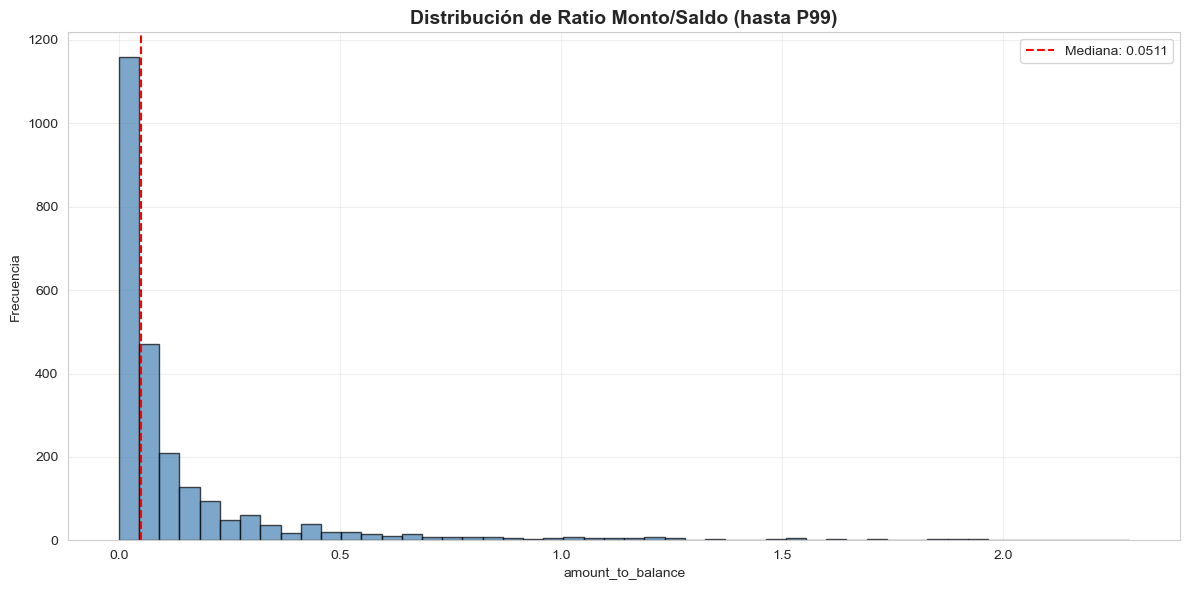

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filtrar outliers extremos para visualización
p99 = df['amount_to_balance'].quantile(0.99)
data_filtered = df[df['amount_to_balance'] <= p99]['amount_to_balance']

ax.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('Distribución de Ratio Monto/Saldo (hasta P99)', fontsize=14, fontweight='bold')
ax.set_xlabel('amount_to_balance')
ax.set_ylabel('Frecuencia')
ax.axvline(data_filtered.median(), color='red', linestyle='--', label=f'Mediana: {data_filtered.median():.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/fe_amount_to_balance_hist.png', dpi=100, bbox_inches='tight')
plt.show()

## Countplot: Proporción de Dispositivos Nuevos

Muestra cuántas transacciones usan dispositivos nuevos vs. ya conocidos por cuenta.

C:\Users\joako\AppData\Local\Temp\ipykernel_34240\2672760479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='new_device_for_account', ax=axes[0], palette='Set2')
C:\Users\joako\AppData\Local\Temp\ipykernel_34240\2672760479.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='new_ip_for_account', ax=axes[1], palette='Set2')


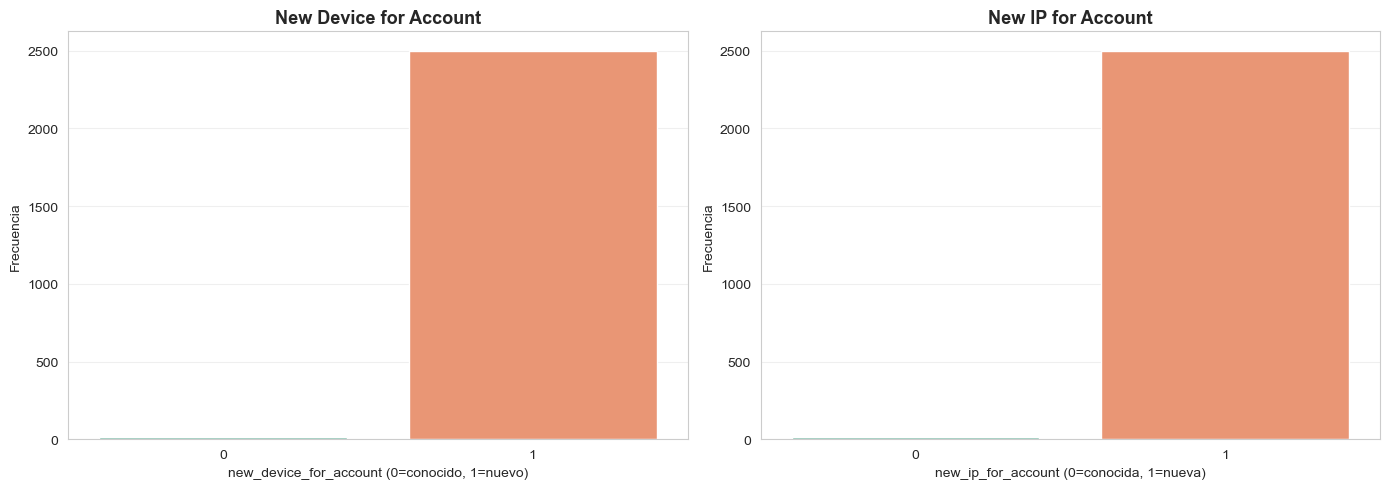

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# new_device_for_account
sns.countplot(data=df, x='new_device_for_account', ax=axes[0], palette='Set2')
axes[0].set_title('New Device for Account', fontsize=13, fontweight='bold')
axes[0].set_xlabel('new_device_for_account (0=conocido, 1=nuevo)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3, axis='y')

# new_ip_for_account
sns.countplot(data=df, x='new_ip_for_account', ax=axes[1], palette='Set2')
axes[1].set_title('New IP for Account', fontsize=13, fontweight='bold')
axes[1].set_xlabel('new_ip_for_account (0=conocida, 1=nueva)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/fe_novelty_features.png', dpi=100, bbox_inches='tight')
plt.show()

## Boxplot: amount_log por Canal

Comparamos la distribución de montos (escala log) entre canales.

C:\Users\joako\AppData\Local\Temp\ipykernel_34240\349330255.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Channel', y='amount_log', ax=ax, palette='Set3')


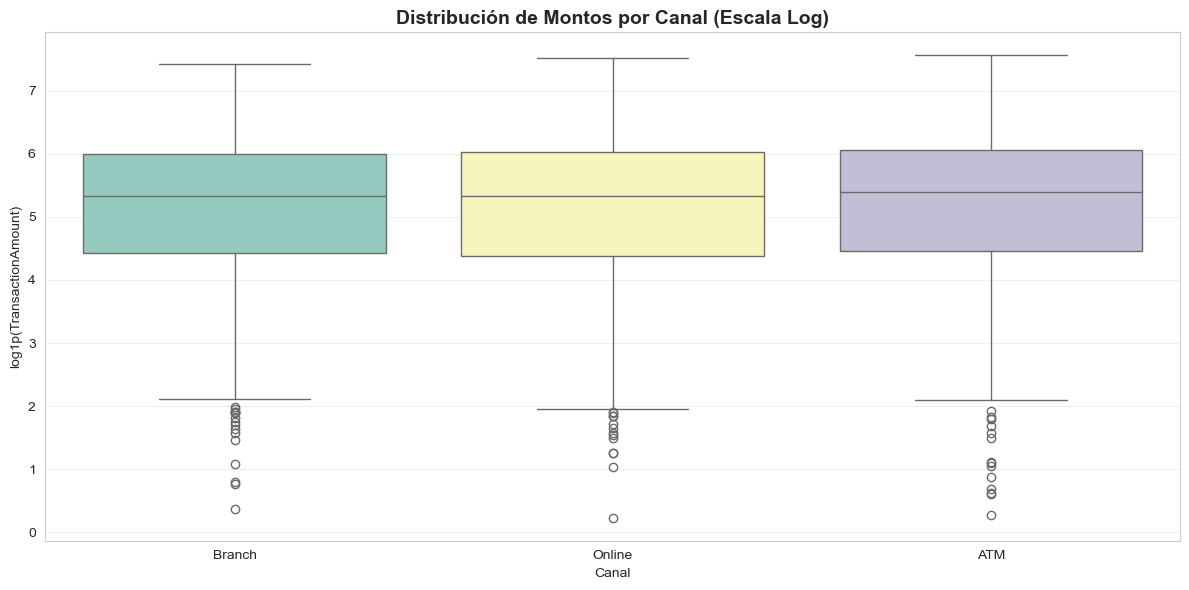

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x='Channel', y='amount_log', ax=ax, palette='Set3')
ax.set_title('Distribución de Montos por Canal (Escala Log)', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('log1p(TransactionAmount)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/fe_amount_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

## Scatter: Velocidad (tx_count_rolling_1d) vs. Monto

Relación entre actividad diaria y monto transaccionado.

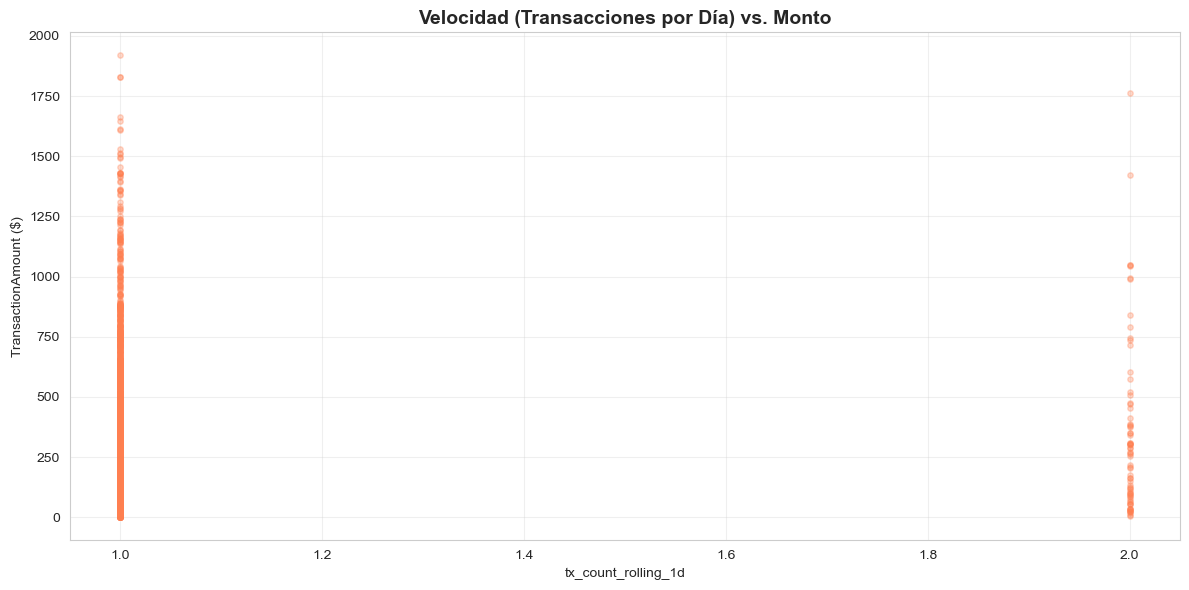

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Muestra aleatoria para mejor visualización
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

ax.scatter(sample_df['tx_count_rolling_1d'], sample_df['TransactionAmount'], 
           alpha=0.3, s=15, color='coral')
ax.set_title('Velocidad (Transacciones por Día) vs. Monto', fontsize=14, fontweight='bold')
ax.set_xlabel('tx_count_rolling_1d')
ax.set_ylabel('TransactionAmount ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/fe_velocity_vs_amount.png', dpi=100, bbox_inches='tight')
plt.show()

## Heatmap: Correlación de Features Numéricas (muestra)

Verificamos correlaciones entre algunas features clave.

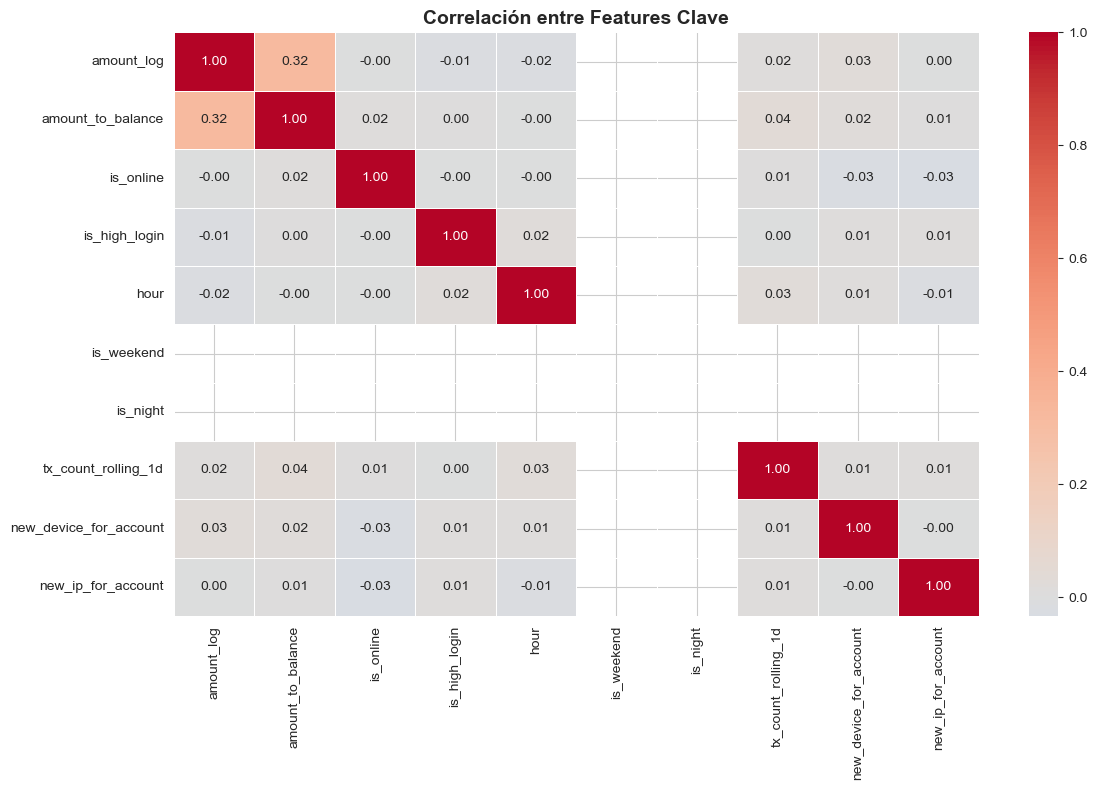

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Seleccionar features numéricas clave
feature_cols = ['amount_log', 'amount_to_balance', 'is_online', 'is_high_login', 
                'hour', 'is_weekend', 'is_night', 'tx_count_rolling_1d', 
                'new_device_for_account', 'new_ip_for_account']

# Filtrar solo las que existen
feature_cols_exists = [col for col in feature_cols if col in df.columns]

corr_matrix = df[feature_cols_exists].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre Features Clave', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/fe_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

---
# F) Preparar Dataset Model-Ready

## Seleccionar Columnas para el Dataset Final

Incluimos columnas originales + todas las features creadas.

In [ ]:
print("Columnas disponibles en df:")
print(f"Total: {len(df.columns)}")
print("\nPrimeras 30 columnas:")
print(list(df.columns[:30]))

Columnas disponibles en df:
Total: 80

Primeras 30 columnas:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate', 'TransactionDate_dt', 'amount_log', 'amount_to_balance', 'is_online', 'is_high_login', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'new_device_for_account', 'new_ip_for_account', 'new_merchant_for_account', 'new_location_for_account']


## Crear df_model_ready

Seleccionamos todas las columnas relevantes. Removemos solo las auxiliares temporales.

In [ ]:
# Columnas a excluir (temporales o redundantes)
cols_to_drop = ['date']  # date fue auxiliar para rolling features

# Crear dataset final
df_model_ready = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"✓ df_model_ready creado")
print(f"  Shape: {df_model_ready.shape}")
print(f"  Columnas: {len(df_model_ready.columns)}")

✓ df_model_ready creado
  Shape: (2512, 79)
  Columnas: 79


## Verificar Valores Nulos

Revisamos si hay valores faltantes en las nuevas features.

In [ ]:
null_counts = df_model_ready.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

if len(null_counts) > 0:
    print("⚠ Columnas con valores nulos:")
    print(null_counts)
else:
    print("✓ No hay valores nulos en df_model_ready")

✓ No hay valores nulos en df_model_ready


## Preview del Dataset Final

Mostramos las primeras filas del dataset listo para modelado.

In [ ]:
print("Primeras 5 filas de df_model_ready:")
print(df_model_ready.head())

print("\nÚltimas 5 columnas (probablemente features agregadas):")
print(list(df_model_ready.columns[-10:]))

Primeras 5 filas de df_model_ready:
  TransactionID AccountID  TransactionAmount      TransactionDate TransactionType     Location DeviceID  \
0      TX001313   AC00001              47.79  2023-09-15 17:00:20           Debit       Denver  D000649   
1      TX002017   AC00001             212.97  2023-11-14 16:56:34           Debit      Atlanta  D000492   
2      TX002121   AC00002             476.99  2023-01-10 16:00:32           Debit    San Diego  D000594   
3      TX000021   AC00002              59.32  2023-02-28 16:36:58           Debit  Los Angeles  D000152   
4      TX001477   AC00002              12.62  2023-05-05 16:35:44           Debit      El Paso  D000475   

        IP Address MerchantID Channel  CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0      59.12.96.11       M034  Branch           25            Student                   37              1   
1    45.241.13.208       M003  Online           59           Engineer                  178             

## Guardar Dataset Model-Ready

Exportamos el dataset final a CSV.

In [ ]:
output_path = 'outputs/tables/df_model_ready.csv'
df_model_ready.to_csv(output_path, index=False)

print(f"✓ Dataset guardado exitosamente en: {output_path}")
print(f"  Shape final: {df_model_ready.shape}")
print(f"  Tamaño del archivo: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

✓ Dataset guardado exitosamente en: outputs/tables/df_model_ready.csv
  Shape final: (2512, 79)
  Tamaño del archivo: 1.56 MB
